# EEGImageNetDataset usage examples

In [1]:
from torch.utils.data import DataLoader
from src.dataset import EEGImageNetDataset
from src.utilities import Args, get_device

In [2]:
args = Args()
device = get_device()

# 1) Recommended: explicit constructor
data = EEGImageNetDataset.from_args(args, map_location=device)

print("dataset size:", len(data))
x, y = data[0]
print("one sample eeg shape:", tuple(x.shape), "label:", y)

loader = DataLoader(data, batch_size=8, shuffle=True)
batch_x, batch_y = next(iter(loader))
print("batch eeg shape:", tuple(batch_x.shape), "batch label shape:", tuple(batch_y.shape))

dataset size: 2000
one sample eeg shape: (62, 400) label: 57
batch eeg shape: (8, 62, 400) batch label shape: (8,)


In [3]:
# Label map from image to index, there are 80 categories in total with 40 coarse categories and 40 fine categories.
data.label_to_index

{'n07758680': 0,
 'n07749192': 1,
 'n12144580': 2,
 'n07740461': 3,
 'n07753275': 4,
 'n07772935': 5,
 'n07756951': 6,
 'n07745940': 7,
 'n02701002': 8,
 'n02901620': 9,
 'n04465666': 10,
 'n03790512': 11,
 'n03845190': 12,
 'n03690473': 13,
 'n03384352': 14,
 'n04389033': 15,
 'n02107142': 16,
 'n02099601': 17,
 'n02112826': 18,
 'n02110185': 19,
 'n02106166': 20,
 'n02106550': 21,
 'n02099712': 22,
 'n02111889': 23,
 'n02992211': 24,
 'n03838899': 25,
 'n03372029': 26,
 'n04487394': 27,
 'n03884397': 28,
 'n04249415': 29,
 'n03495258': 30,
 'n02672831': 31,
 'n02643566': 32,
 'n01443537': 33,
 'n01456756': 34,
 'n01494475': 35,
 'n01496331': 36,
 'n02655020': 37,
 'n01484850': 38,
 'n02630281': 39,
 'n03590841': 40,
 'n02124075': 41,
 'n11939491': 42,
 'n04120489': 43,
 'n03982430': 44,
 'n03877472': 45,
 'n03445777': 46,
 'n03792972': 47,
 'n02992529': 48,
 'n03100240': 49,
 'n03272010': 50,
 'n03888257': 51,
 'n07753592': 52,
 'n02281787': 53,
 'n04044716': 54,
 'n02906734': 55,
 '

## Filter by subject and granularity

### filter by granularity

In [4]:
granularity_filter_data = EEGImageNetDataset(
    dataset_dir="data",
    subject=-1,         # -1 means all subjects
    granularity="fine", # or "coarse", "all"
    eeg_window=(40, 440),
)

print("fine dataset size:", len(granularity_filter_data))

fine dataset size: 32000


### filter by subject

In [5]:
subject_filter_data = EEGImageNetDataset(
    dataset_dir="data",
    subject=1,         # -1 means all subjects
    granularity="all", # or "coarse", "fine"
    eeg_window=(40, 440),
)

print("subject 1 dataset size:", len(subject_filter_data))

subject 1 dataset size: 4000


## EEG visualization example

In [13]:
x.shape

torch.Size([62, 400])

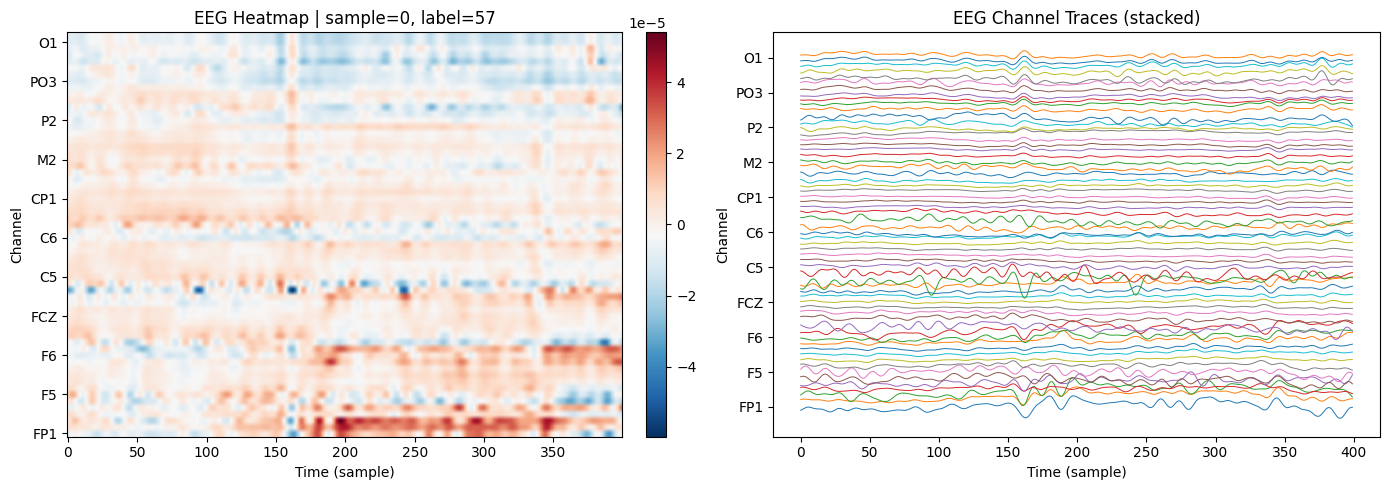

eeg shape: (62, 400) label: 57


In [14]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load channel names
with open("data/mode/montage_ch_names.json") as f:
    all_ch_names = json.load(f)
ch_names = all_ch_names[:62]  # first 62 are EEG electrodes

# Pick any sample index
sample_idx = 0
feat, label = data[sample_idx]  # feat shape: (channels, timesteps)

eeg = feat.detach().cpu().numpy() if hasattr(feat, "detach") else np.asarray(feat)
channels, timesteps = eeg.shape

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Heatmap
im = axes[0].imshow(eeg, aspect="auto", cmap="RdBu_r", origin="lower")
axes[0].set_title(f"EEG Heatmap | sample={sample_idx}, label={label}")
axes[0].set_xlabel("Time (sample)")
axes[0].set_ylabel("Channel")
step = max(1, channels // 10)
axes[0].set_yticks(range(0, channels, step))
axes[0].set_yticklabels(ch_names[::step])
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# 2) Stacked channel traces
scale = np.std(eeg) * 2.0 if np.std(eeg) > 0 else 1.0
time = np.arange(timesteps)
offsets = np.arange(channels) * scale
axes[1].plot(time, (eeg + offsets[:, None]).T, linewidth=0.7)
axes[1].set_title("EEG Channel Traces (stacked)")
axes[1].set_xlabel("Time (sample)")
axes[1].set_ylabel("Channel")
axes[1].set_yticks(offsets[::step])
axes[1].set_yticklabels(ch_names[::step])

plt.tight_layout()
plt.show()

print("eeg shape:", eeg.shape, "label:", label)